In [ ]:
"""
Cardiac Arrhythmia Classification — Deep Learning Pipeline
===========================================================
Architecture : 1-D CNN + Squeeze-and-Excitation + Bidirectional GRU
Training     : 5-Fold Stratified Cross-Validation with Focal Loss
Inference    : Soft-Voting Ensemble + Per-Class Threshold Tuning
"""

# ── Standard library ──────────────────────────────────────────────────────────
import os
import json
import pickle

# ── Third-party ───────────────────────────────────────────────────────────────
import numpy as np
import h5py
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers, models, backend as K
from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score,classification_report,confusion_matrix,ConfusionMatrixDisplay


In [ ]:
# Google Colab — comment out when running locally
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
TRAIN_DATA_PATH  = "/content/drive/MyDrive/Proyecto_DEEP_LEARNING/training_set_500.h5"
TEST_DATA_PATH   = "/content/drive/MyDrive/Proyecto_DEEP_LEARNING/test_without_labels_200.h5"
CHECKPOINT_DIR   = "/content/drive/MyDrive/Proyecto_DEEP_LEARNING/checkpoints_skf/"
OUTPUT_PRED_PATH = "/content/drive/MyDrive/Proyecto_DEEP_LEARNING/final_predictions_skf.npy"
TEST_LABELS_PATH = "/content/drive/MyDrive/Proyecto_DEEP_LEARNING/test_with_labels_200.h5"
training_curves_path = os.path.join(CHECKPOINT_DIR, "training_curves.png")
dashboard_path = os.path.join(CHECKPOINT_DIR, "performance_dashboard.png")
ft_curves_path = os.path.join(CHECKPOINT_DIR, "finetuning_curves.png")
test_eval_path = os.path.join(CHECKPOINT_DIR, "final_test_confusion_matrix.png")
dashboard_summary_path = os.path.join(CHECKPOINT_DIR, "composite_dashboard_summary.png")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

INPUT_SHAPE         = (2049, 1)
EMBED_DIM           = 64
NUM_CLASSES         = 3
CLASS_NAMES         = ["Normal", "Arrhythmia", "Noise"]
N_FOLDS             = 5
BATCH_SIZE          = 32
LEARNING_RATE       = 0.001
MAX_EPOCHS          = 40
LR_PATIENCE         = 3
EARLY_STOP_PATIENCE = 50
RANDOM_SEED = 42
FOCAL_GAMMA = 3.0
FOCAL_ALPHA = 1.0
LABEL_SMOOTHING = 0.05
WEIGHT_DECAY = 0.01
LR_REDUCE_FACTOR = 0.5
MIN_LEARNING_RATE = 1e-6
#Trining and validation curves
TRAIN_COLOR   = "#2c3e50"
VAL_COLOR     = "#e74c3c"
BEST_EPOCH_COLOR = "#27ae60"
PEAK_VALUE_COLOR = "#8e44ad"
BAND_ALPHA    = 0.2
DPI=400
LAYOUT = "double_column"
#Fine tunning
FINE_TUNE_LEARNING_RATE = 1e-5
FINE_TUNE_EPOCHS = 15
FINE_TUNE_ES_PATIENCE = 5
#Threshold tuning (grid search)
THRESHOLD_MIN = 0.20
THRESHOLD_MAX = 0.80
THRESHOLD_STEPS = 15
DEFAULT_THRESHOLD = 0.33
DIGITS=4


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# DATA LOADING
# ─────────────────────────────────────────────────────────────────────────────
print("Loading data from HDF5 files …")

with h5py.File(TRAIN_DATA_PATH, "r") as h5_file:
    X_train        = np.array(h5_file["data"],    dtype=np.float32)
    y_train        = np.squeeze(np.array(h5_file["labels"],  dtype=np.int32))
    patient_groups = np.squeeze(np.array(h5_file["patient"], dtype=np.int32))

with h5py.File(TEST_DATA_PATH, "r") as h5_file:
    X_test_raw = np.array(h5_file["data"], dtype=np.float32)

print(f"Dataset loaded — train: {X_train.shape[0]} samples | test: {X_test_raw.shape[0]} samples")


# ─────────────────────────────────────────────────────────────────────────────
# PREPROCESSING
# ─────────────────────────────────────────────────────────────────────────────
def z_score_normalize(X: np.ndarray) -> np.ndarray:
    """Per-sample Z-score normalisation along the time axis."""
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1,  keepdims=True) + 1e-8
    return (X - mean) / std


X_train    = z_score_normalize(X_train)
X_test_raw = z_score_normalize(X_test_raw)

# Add channel dimension: (N, 2049, 1)
X_train_3d = np.expand_dims(X_train, axis=-1) if X_train.ndim == 2 else X_train
X_test_3d  = np.expand_dims(X_test_raw, axis=-1) if X_test_raw.ndim == 2 else X_test_raw

# One-hot labels
y_train_onehot = tf.keras.utils.to_categorical(y_train, num_classes=NUM_CLASSES)



Loading data from HDF5 files …
Dataset loaded — train: 116953 samples | test: 46943 samples


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# MODEL ARCHITECTURE
# ─────────────────────────────────────────────────────────────────────────────
def squeeze_excitation_block(
    input_tensor: tf.Tensor,
    reduction_ratio: int = 8,
) -> tf.Tensor:
    """
    1-D Squeeze-and-Excitation attention block.
    Input shape : (Batch, Length, Channels)
    Output shape: (Batch, Length, Channels)
    """
    num_channels = input_tensor.shape[-1]

    # Squeeze: global context descriptor
    context_vector = layers.GlobalAveragePooling1D()(input_tensor)

    # Excitation: two-layer bottleneck MLP
    excitation = layers.Dense(
        num_channels // reduction_ratio,
        activation="relu",
        kernel_initializer="he_normal",
    )(context_vector)
    excitation = layers.Dense(num_channels, activation="sigmoid")(excitation)
    excitation = layers.Reshape((1, num_channels))(excitation)

    # Feature recalibration
    recalibrated = layers.Multiply()([input_tensor, excitation])
    return recalibrated


def build_ecg_classifier(
    input_shape: tuple = (2049, 1),
    num_classes: int = 3,
) -> tf.keras.Model:
    """
    1-D CNN with SE-Attention and Bidirectional GRU head.

    Stage 1 : Conv1D(32,  k=7) -> BN -> ReLU -> MaxPool(2) -> Dropout(0.2)
    Stage 2 : Conv1D(64,  k=5) -> BN -> ReLU -> MaxPool(2) -> Dropout(0.2)
    Stage 3 : Conv1D(128, k=3) -> BN -> ReLU -> MaxPool(2) -> Dropout(0.2)
    Stage 4 : Conv1D(256, k=3) -> BN -> ReLU -> SE-Block
    Head    : BiGRU(64) -> Dense(128) -> Dropout(0.5) -> Softmax(num_classes)
    """
    inputs = layers.Input(shape=input_shape)

    # Stage 1
    x = layers.Conv1D(32, kernel_size=7, padding="same", kernel_initializer="he_normal")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)

    # Stage 2
    x = layers.Conv1D(64, kernel_size=5, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)

    # Stage 3
    x = layers.Conv1D(128, kernel_size=3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)

    # Stage 4
    x = layers.Conv1D(256, kernel_size=3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    # Attention module
    x = squeeze_excitation_block(x, reduction_ratio=8)

    # Sequence encoder
    x = layers.Bidirectional(layers.GRU(64, return_sequences=False))(x)

    # Classification head
    x = layers.Dense(128, activation="relu", kernel_initializer="he_normal")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs=inputs, outputs=outputs, name="ECGNet_SE_BiGRU")


# ─────────────────────────────────────────────────────────────────────────────
# CUSTOM LOSS — FOCAL LOSS WITH LABEL SMOOTHING
# ─────────────────────────────────────────────────────────────────────────────
def focal_loss(gamma: float = 3.0, alpha: float = 1.0, label_smoothing: float = 0.05):
    """
    Multiclass Focal Loss with label smoothing.

    Parameters
    ----------
    gamma          : focusing exponent (higher: harder examples weighted more)
    alpha          : scaling factor
    label_smoothing: soft label coefficient
    """
    def focal_loss_fixed(y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
        y_true      = tf.cast(y_true, tf.float32)
        num_classes = tf.cast(tf.shape(y_true)[-1], tf.float32)
        y_true      = y_true * (1.0 - label_smoothing) + (label_smoothing / num_classes)
        y_pred      = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1.0 - tf.keras.backend.epsilon())
        cross_entropy = -y_true * tf.math.log(y_pred)
        focal_weight  = alpha * tf.math.pow(1.0 - y_pred, gamma)
        return tf.reduce_sum(focal_weight * cross_entropy, axis=-1)

    return focal_loss_fixed


# ─────────────────────────────────────────────────────────────────────────────
# CUSTOM CALLBACKS
# ─────────────────────────────────────────────────────────────────────────────
class TrainingStateCheckpoint(tf.keras.callbacks.Callback):
    """
    Persists model weights and optimiser state at each epoch end
    to allow seamless training resumption after interruptions.
    """

    def __init__(self, checkpoint_dir: str, fold_index: int):
        super().__init__()
        self.checkpoint_dir = checkpoint_dir
        self.fold_index     = fold_index
        self.state_path     = os.path.join(checkpoint_dir, f"training_state_fold_{fold_index}.pkl")

    def on_epoch_end(self, epoch: int, logs: dict = None):
        weights_path = os.path.join(
            self.checkpoint_dir, f"resume_weights_fold_{self.fold_index}.weights.h5"
        )
        self.model.save_weights(weights_path)

        state = {
            "epoch": epoch + 1,
            "fold":  self.fold_index,
            "logs":  logs,
            "lr":    float(self.model.optimizer.learning_rate),
        }
        with open(self.state_path, "wb") as fp:
            pickle.dump(state, fp)


class F1MacroCallback(tf.keras.callbacks.Callback):
    """
    Computes and logs val_f1_macro at the end of each epoch.
    Injecting it into `logs` makes it available to all other callbacks
    (e.g. ModelCheckpoint, ReduceLROnPlateau) and to history.history.

    Parameters
    ----------
    val_data : tuple (X_val, y_val_onehot)
    """

    def __init__(self, val_data: tuple):
        super().__init__()
        self.X_val = val_data[0]
        self.y_val = val_data[1]           # one-hot

    def on_epoch_end(self, epoch: int, logs: dict = None):
        val_probs  = self.model.predict(self.X_val, verbose=0)
        val_preds  = np.argmax(val_probs,  axis=-1)
        val_true   = np.argmax(self.y_val, axis=-1)
        score      = f1_score(val_true, val_preds, average="macro", zero_division=0)
        logs["val_f1_macro"] = score


class HistoryPersistenceCallback(tf.keras.callbacks.Callback):
    """
    Appends epoch metrics to a JSON file after every epoch so that
    training history survives Colab disconnections and multi-account runs.

    The JSON stores lists for every key in `logs` (loss, accuracy,
    val_loss, val_accuracy, val_f1_macro, …).  On resumption the new
    epochs are appended rather than overwriting previous data.

    Parameters
    ----------
    history_path : full path to the target .json file
    """

    def __init__(self, history_path: str):
        super().__init__()
        self.history_path = history_path

    def on_epoch_end(self, epoch: int, logs: dict = None):
        logs = logs or {}

        # Load existing data if the file already exists (resumed run)
        if os.path.exists(self.history_path):
            with open(self.history_path, "r") as fp:
                stored = json.load(fp)
        else:
            stored = {}

        # Append current epoch values
        for key, value in logs.items():
            stored.setdefault(key, []).append(float(value))

        with open(self.history_path, "w") as fp:
            json.dump(stored, fp, indent=2)



In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# TRAINING — STRATIFIED K-FOLD CROSS-VALIDATION
# ─────────────────────────────────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
oof_probabilities = np.zeros((X_train.shape[0], NUM_CLASSES))

print(f"\nStarting {N_FOLDS}-Fold cross-validation with Focal Loss …\n")

for fold_idx, (train_indices, val_indices) in enumerate(skf.split(X_train, y_train)):
    print(f"\n{'─'*60}")
    print(f"  FOLD {fold_idx + 1} / {N_FOLDS}")
    print(f"{'─'*60}")

    X_fold_train, y_fold_train = X_train_3d[train_indices], y_train_onehot[train_indices]
    X_fold_val,   y_fold_val   = X_train_3d[val_indices],   y_train_onehot[val_indices]

    # ── Build and compile model ───────────────────────────────────────────────
    model = build_ecg_classifier(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES)
    optimizer = tf.keras.optimizers.AdamW(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    model.compile(
        optimizer=optimizer,
        loss=focal_loss(),
        metrics=["accuracy"],
    )

    # ── Resume from checkpoint if available ──────────────────────────────────
    state_path   = os.path.join(CHECKPOINT_DIR, f"training_state_fold_{fold_idx + 1}.pkl")
    weights_path = os.path.join(CHECKPOINT_DIR, f"resume_weights_fold_{fold_idx + 1}.weights.h5")
    start_epoch  = 0

    if os.path.exists(state_path) and os.path.exists(weights_path):
        with open(state_path, "rb") as fp:
            saved_state = pickle.load(fp)
        start_epoch = saved_state["epoch"]
        model.load_weights(weights_path)
        model.optimizer.learning_rate.assign(saved_state["lr"])
        print(f"  Resuming from epoch {start_epoch}")
    else:
        print("  Starting from scratch")

    # ── Callbacks ─────────────────────────────────────────────────────────────
    best_model_path = os.path.join(CHECKPOINT_DIR, f"best_model_fold_{fold_idx + 1}.keras")
    history_path    = os.path.join(CHECKPOINT_DIR, f"history_fold_{fold_idx + 1}.json")

    callbacks = [
        F1MacroCallback(val_data=(X_fold_val, y_fold_val)),   # must be first -> injects val_f1_macro into logs
        ModelCheckpoint(
            filepath=best_model_path,
            monitor="val_loss",
            save_best_only=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=LR_REDUCE_FACTOR,
            patience=LR_PATIENCE,
            verbose=1,
            min_lr=MIN_LEARNING_RATE,
        ),
        EarlyStopping(
            monitor="val_loss",
            patience=EARLY_STOP_PATIENCE,
            verbose=1,
            restore_best_weights=True,
        ),
        TrainingStateCheckpoint(checkpoint_dir=CHECKPOINT_DIR, fold_index=fold_idx + 1),
        HistoryPersistenceCallback(history_path=history_path),  # must be last -> all metrics already in logs
    ]

    # ── Fit ───────────────────────────────────────────────────────────────────
    model.fit(
        X_fold_train, y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=MAX_EPOCHS,
        initial_epoch=start_epoch,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )

    # ── OOF predictions ───────────────────────────────────────────────────────
    best_model = models.load_model(
        best_model_path,
        custom_objects={"focal_loss_fixed": focal_loss()},
    )
    oof_probabilities[val_indices] = best_model.predict(X_fold_val, batch_size=BATCH_SIZE)



Starting 5-Fold cross-validation with Focal Loss …


────────────────────────────────────────────────────────────
  FOLD 1 / 5
────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 62 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  Resuming from epoch 40
731/731 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step

────────────────────────────────────────────────────────────
  FOLD 2 / 5
────────────────────────────────────────────────────────────
  Resuming from epoch 40
731/731 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step

────────────────────────────────────────────────────────────
  FOLD 3 / 5
────────────────────────────────────────────────────────────
  Resuming from epoch 40
731/731 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step

────────────────────────────────────────────────────────────
  FOLD 4 / 5
────────────────────────────────────────────────────────────
  Resuming from epoch 40
731/731 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step

────────────────────────────────────────────────────────────
  FOLD 5 / 5
────────────────────────────────────────────────────────────
  Resuming from epoch 40
731/731 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step


In [ ]:
def save_figure_both_formats(fig_or_plt, base_path: str, dpi: int = DPI) -> None:
    """
    Saves the current figure (or a given figure object) in both PNG and PDF formats.
    `base_path` should end in .png; the .pdf version is derived automatically.
    """
    png_path = base_path if base_path.endswith(".png") else base_path + ".png"
    pdf_path = png_path.replace(".png", ".pdf")
    plt.savefig(png_path, dpi=dpi, bbox_inches="tight")
    plt.savefig(pdf_path, dpi=dpi, bbox_inches="tight")

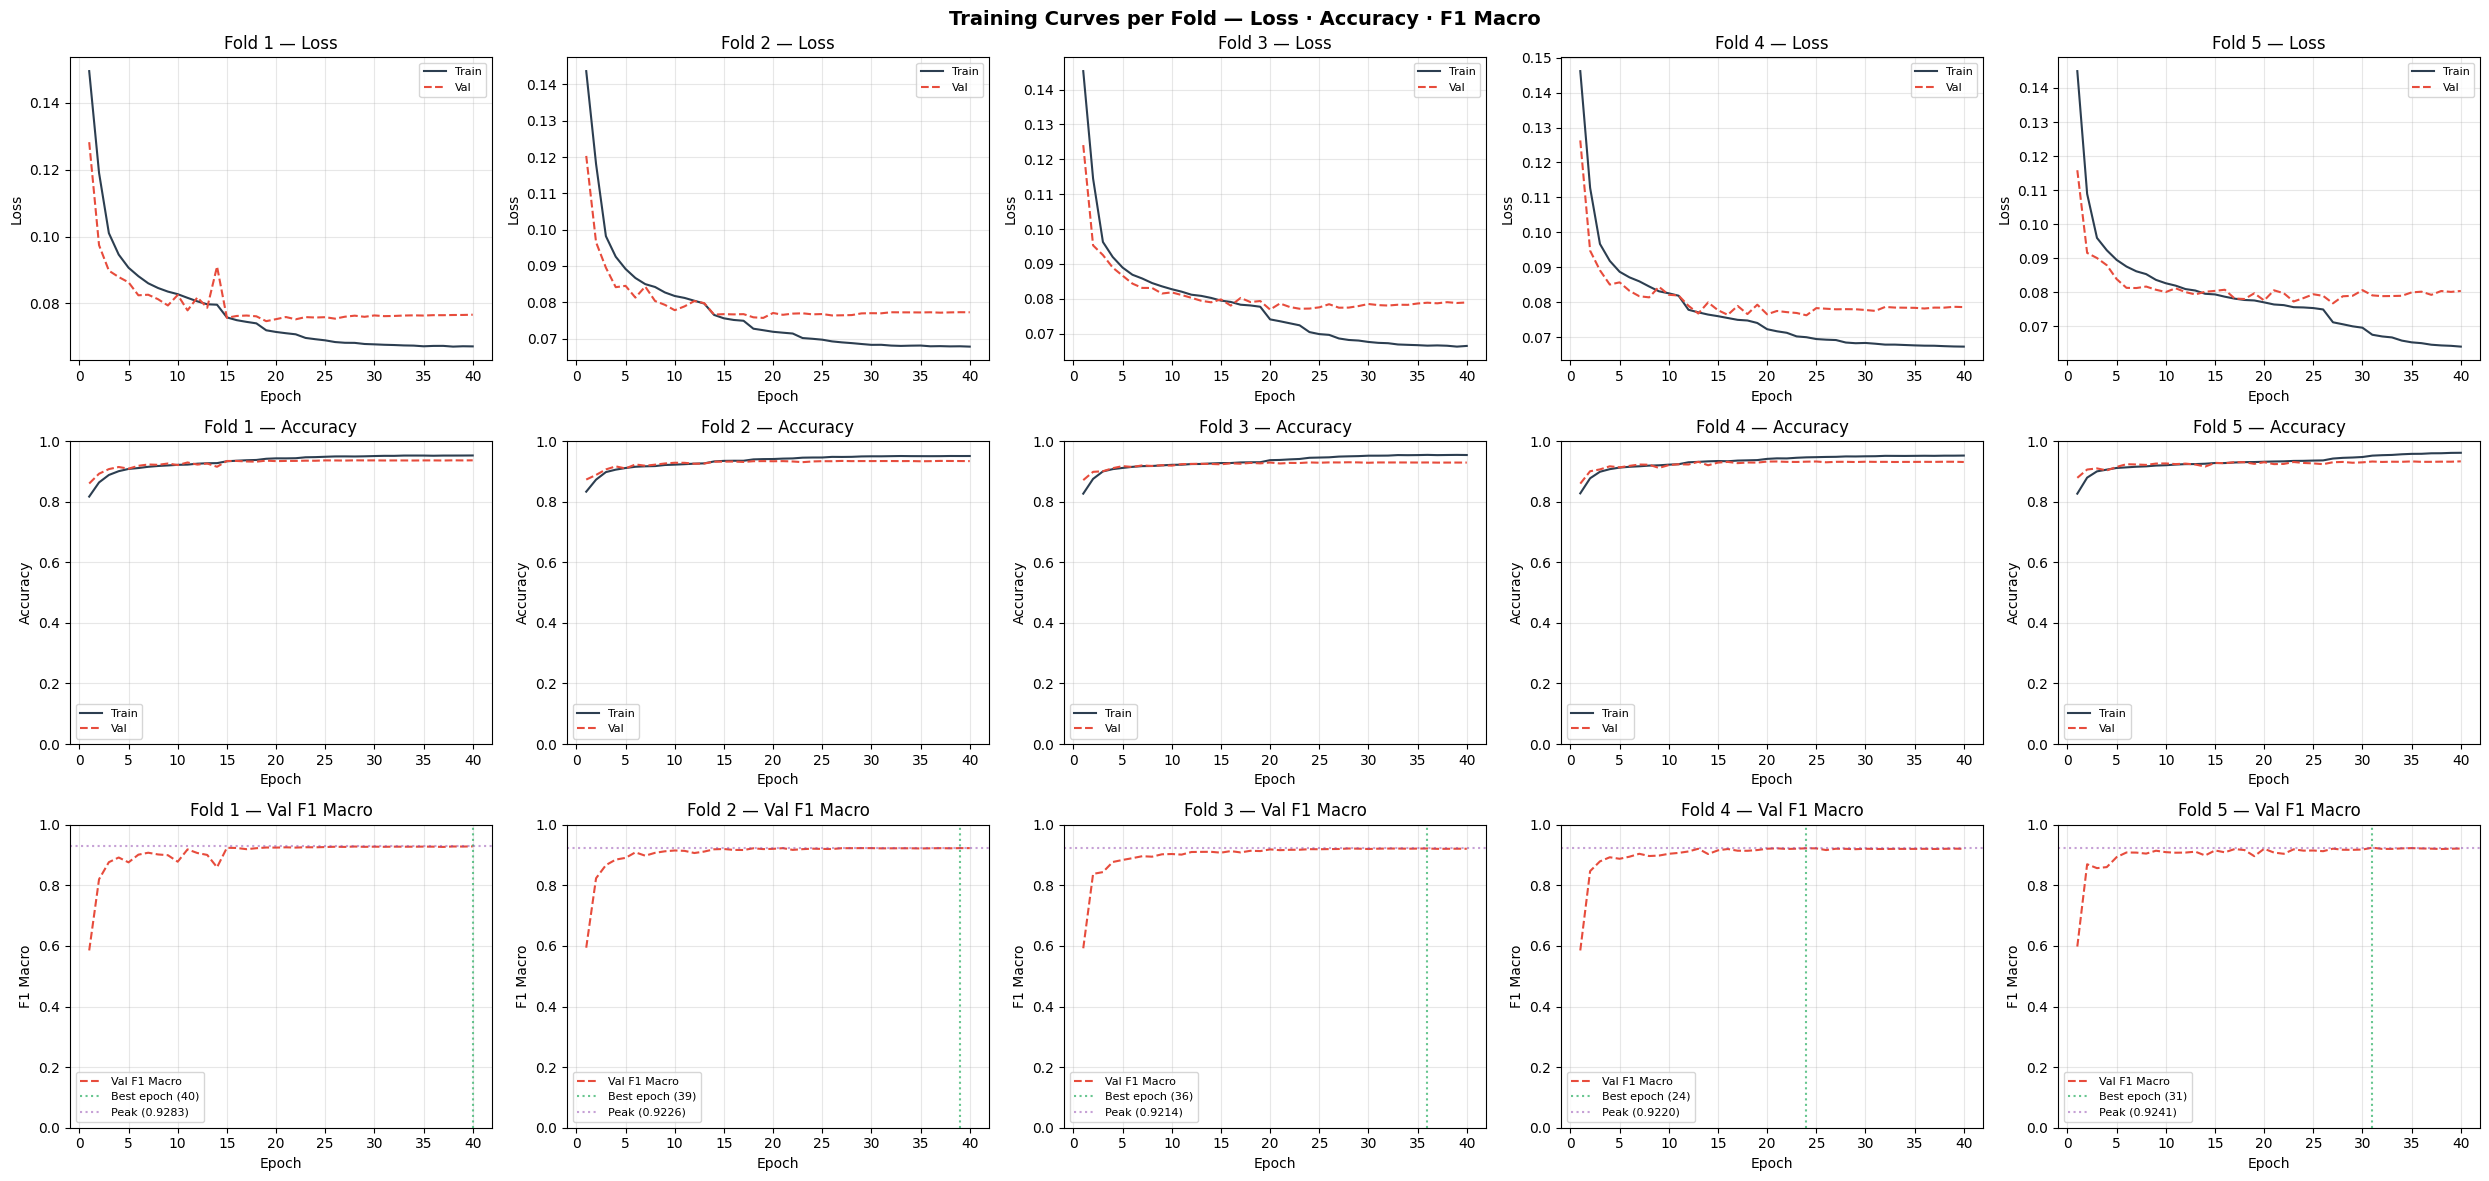

Training curves saved in /content/drive/MyDrive/Proyecto_DEEP_LEARNING/checkpoints_skf/training_curves.png


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# TRAINING CURVES — LOSS, ACCURACY AND F1 PER FOLD
# ─────────────────────────────────────────────────────────────────────────────
def plot_training_curves(checkpoint_dir: str, n_folds: int) -> None:
    """
    Loads the persisted JSON history for every fold and renders a
    3-row × N_FOLDS grid showing Loss, Accuracy and F1 Macro curves.
    The figure is saved to `checkpoint_dir/training_curves.png`.
    """
    fig, axes = plt.subplots(3, n_folds, figsize=(5 * n_folds, 12))
    fig.suptitle(
        "Training Curves per Fold — Loss · Accuracy · F1 Macro",
        fontsize=14,
        fontweight="bold",
    )

    row_titles = ["Loss", "Accuracy", "F1 Macro (val)"]
    colors     = {"train": "#2c3e50", "val": "#e74c3c"}

    for fold_idx in range(n_folds):
        history_path = os.path.join(checkpoint_dir, f"history_fold_{fold_idx + 1}.json")

        if not os.path.exists(history_path):
            for row in range(3):
                axes[row, fold_idx].set_visible(False)
            continue

        with open(history_path, "r") as fp:
            hist = json.load(fp)

        epochs = range(1, len(hist.get("loss", [])) + 1)

        # ── Row 0: Loss ───────────────────────────────────────────────────────
        ax = axes[0, fold_idx]
        ax.plot(epochs, hist.get("loss",     []), color=colors["train"], label="Train")
        ax.plot(epochs, hist.get("val_loss", []), color=colors["val"],   label="Val",   linestyle="--")
        ax.set_title(f"Fold {fold_idx + 1} — Loss")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

        # ── Row 1: Accuracy ───────────────────────────────────────────────────
        ax = axes[1, fold_idx]
        ax.plot(epochs, hist.get("accuracy",     []), color=colors["train"], label="Train")
        ax.plot(epochs, hist.get("val_accuracy", []), color=colors["val"],   label="Val",   linestyle="--")
        ax.set_title(f"Fold {fold_idx + 1} — Accuracy")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy")
        ax.set_ylim([0, 1.0])
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

        # ── Row 2: F1 Macro (validation only — no train F1 tracked) ──────────
        ax = axes[2, fold_idx]
        val_f1 = hist.get("val_f1_macro", [])
        if val_f1:
            ax.plot(epochs, val_f1, color=colors["val"], label="Val F1 Macro", linestyle="--")
            best_epoch = int(np.argmax(val_f1)) + 1
            ax.axvline(best_epoch, color="#27ae60", linestyle=":", alpha=0.7,
                       label=f"Best epoch ({best_epoch})")
            ax.axhline(max(val_f1), color="#8e44ad", linestyle=":", alpha=0.5,
                       label=f"Peak ({max(val_f1):.4f})")
        ax.set_title(f"Fold {fold_idx + 1} — Val F1 Macro")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("F1 Macro")
        ax.set_ylim([0, 1.0])
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    save_figure_both_formats(plt, training_curves_path)
    plt.show()
    print(f"Training curves saved in {training_curves_path}")


plot_training_curves(CHECKPOINT_DIR, N_FOLDS)

In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# EVALUATION — RELOAD BEST CHECKPOINTS AND COMPUTE METRICS
# ─────────────────────────────────────────────────────────────────────────────
print("\n\nReloading best checkpoints for evaluation …")

fold_macro_f1_scores = []
fold_per_class_f1    = []
val_probabilities    = []
val_true_labels      = []
test_fold_probs      = []

for fold_idx, (train_indices, val_indices) in enumerate(skf.split(X_train, y_train)):
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"best_model_fold_{fold_idx + 1}.keras")

    if not os.path.exists(checkpoint_path):
        print(f"  Checkpoint for fold {fold_idx + 1} not found — skipping.")
        continue

    eval_model = models.load_model(
        checkpoint_path,
        custom_objects={"focal_loss_fixed": focal_loss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA, label_smoothing=LABEL_SMOOTHING)},
    )

    X_fold_val      = X_train_3d[val_indices]
    y_fold_val_true = y_train[val_indices]

    val_probs = eval_model.predict(X_fold_val, batch_size=BATCH_SIZE, verbose=0)
    val_preds = np.argmax(val_probs, axis=-1)

    macro_f1     = f1_score(y_fold_val_true, val_preds, average="macro")
    per_class_f1 = f1_score(y_fold_val_true, val_preds, average=None)

    fold_macro_f1_scores.append(macro_f1)
    fold_per_class_f1.append(per_class_f1)
    val_true_labels.append(y_fold_val_true)
    val_probabilities.append(val_probs)

    print(f"\n{'='*50}")
    print(f"  Fold {fold_idx + 1} — Validation Results")
    print(f"{'='*50}")
    print(f"  F1 Macro : {macro_f1:.4f}")
    print(classification_report(y_fold_val_true, val_preds, target_names=CLASS_NAMES, digits=DIGITS))

    test_fold_probs.append(eval_model.predict(X_test_3d, batch_size=BATCH_SIZE, verbose=0))





Reloading best checkpoints for evaluation …

  Fold 1 — Validation Results
  F1 Macro : 0.9246
              precision    recall  f1-score   support

      Normal     0.9423    0.9537    0.9479     13040
  Arrhythmia     0.9134    0.8980    0.9056       951
       Noise     0.9273    0.9133    0.9202      9400

    accuracy                         0.9352     23391
   macro avg     0.9276    0.9217    0.9246     23391
weighted avg     0.9351    0.9352    0.9351     23391


  Fold 2 — Validation Results
  F1 Macro : 0.9194
              precision    recall  f1-score   support

      Normal     0.9443    0.9499    0.9471     13039
  Arrhythmia     0.9075    0.8770    0.8920       951
       Noise     0.9213    0.9168    0.9191      9401

    accuracy                         0.9336     23391
   macro avg     0.9244    0.9146    0.9194     23391
weighted avg     0.9336    0.9336    0.9336     23391


  Fold 3 — Validation Results
  F1 Macro : 0.9184
              precision    recall  f1-s

In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# FINE-TUNING — LAST-LAYER ADAPTATION
# ─────────────────────────────────────────────────────────────────────────────
print("\n\nFine-tuning best models (last 3 layers unfrozen) …")

for fold_idx, (train_indices, val_indices) in enumerate(skf.split(X_train, y_train)):
    base_ckpt      = os.path.join(CHECKPOINT_DIR, f"best_model_fold_{fold_idx + 1}.keras")
    finetuned_ckpt = os.path.join(CHECKPOINT_DIR, f"best_model_fold_{fold_idx + 1}_finetuned.keras")
    ft_history_path = os.path.join(CHECKPOINT_DIR, f"history_fold_{fold_idx + 1}_finetuned.json")

    if not os.path.exists(base_ckpt):
        print(f"  Base checkpoint for fold {fold_idx + 1} not found — skipping.")
        continue

    pretrained_model = models.load_model(
        base_ckpt,
        custom_objects={"focal_loss_fixed": focal_loss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA, label_smoothing=LABEL_SMOOTHING)},
    )

    # Freeze all layers except the last three
    for layer in pretrained_model.layers[:-3]:
        layer.trainable = False

    pretrained_model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=FINE_TUNE_LEARNING_RATE, weight_decay=WEIGHT_DECAY),
        loss=focal_loss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA, label_smoothing=LABEL_SMOOTHING),
        metrics=["accuracy"],
    )

    X_fold_train, y_fold_train = X_train_3d[train_indices], y_train_onehot[train_indices]
    X_fold_val,   y_fold_val   = X_train_3d[val_indices],   y_train_onehot[val_indices]

    pretrained_model.fit(
        X_fold_train, y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=FINE_TUNE_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[
            F1MacroCallback(val_data=(X_fold_val, y_fold_val)),
            ModelCheckpoint(finetuned_ckpt, monitor="val_loss", save_best_only=True, verbose=1),
            EarlyStopping(monitor="val_loss", patience=FINE_TUNE_ES_PATIENCE, restore_best_weights=True),
            HistoryPersistenceCallback(history_path=ft_history_path),
        ],
        verbose=1,
    )
    print(f"  Fold {fold_idx + 1} fine-tuned model saved: {finetuned_ckpt}")



Fine-tuning best models (last 3 layers unfrozen) …
Epoch 1/15
2923/2924 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9459 - loss: 0.0701
Epoch 1: val_loss improved from None to 0.07493, saving model to /content/drive/MyDrive/Proyecto_DEEP_LEARNING/checkpoints_skf/best_model_fold_1_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Proyecto_DEEP_LEARNING/checkpoints_skf/best_model_fold_1_finetuned.keras
2924/2924 ━━━━━━━━━━━━━━━━━━━━ 63s 21ms/step - accuracy: 0.9447 - loss: 0.0704 - val_accuracy: 0.9355 - val_loss: 0.0749 - val_f1_macro: 0.9263
Epoch 2/15
2921/2924 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9445 - loss: 0.0703
Epoch 2: val_loss did not improve from 0.07493
2924/2924 ━━━━━━━━━━━━━━━━━━━━ 59s 20ms/step - accuracy: 0.9451 - loss: 0.0703 - val_accuracy: 0.9354 - val_loss: 0.0750 - val_f1_macro: 0.9259
Epoch 3/15
2921/2924 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9443 - loss: 0.0706
Epoch 3: val_loss did not improve from 0.07493
2924/2

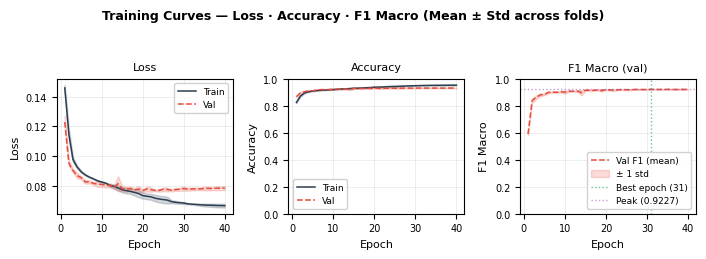

Aggregated figure saved to /content/drive/MyDrive/Proyecto_DEEP_LEARNING/checkpoints_skf/training_curves_aggregated_double_column.png (and its .pdf version)


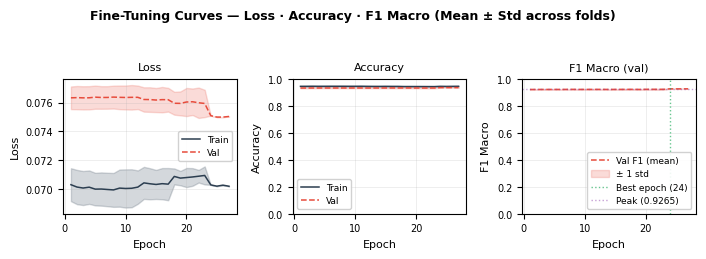

Aggregated figure saved to /content/drive/MyDrive/Proyecto_DEEP_LEARNING/checkpoints_skf/training_curves_aggregated_finetuned_double_column.png (and its .pdf version)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAINING CURVES — LOSS, ACCURACY AND F1 MACRO (MEAN ± STD ACROSS FOLDS)
# Works for both the initial cross-validation training and the fine-tuning
# stage (history_fold_{i}.json vs. history_fold_{i}_finetuned.json). Sized
# for direct insertion as an IEEE figure (no rescaling in Word/LaTeX), so
# all text prints at the specified point sizes. Supports a single-column
# (3 rows x 1 col) and a double-column (1 row x 3 cols) layout.
# ─────────────────────────────────────────────────────────────────────────────

# ── Layout selection ────────────────────────────────────────────────────────
# "single_column" : 3 rows x 1 col, width ≈ IEEE single-column (3.5 in)
# "double_column" : 1 row x 3 cols, width ≈ IEEE double-column (7.16 in)


LAYOUT_CONFIG = {
    "single_column": {
        "figsize": (3.5, 7.3),
        "nrows": 3,
        "ncols": 1,
        "suptitle_fontsize": 8.5,
        "title_fontsize": 8,
        "axis_label_fontsize": 7.5,
        "tick_label_fontsize": 7,
        "legend_fontsize": 6.5,
    },
    "double_column": {
        "figsize": (7.16, 2.6),
        "nrows": 1,
        "ncols": 3,
        "suptitle_fontsize": 9,
        "title_fontsize": 8,
        "axis_label_fontsize": 8,
        "tick_label_fontsize": 7,
        "legend_fontsize": 6.5,
    },
}


def _style_axis(ax, cfg: dict) -> None:
    """Applies consistent, print-legible font sizes to a single axis."""
    ax.tick_params(axis="both", which="major", labelsize=cfg["tick_label_fontsize"])
    ax.title.set_fontsize(cfg["title_fontsize"])
    ax.xaxis.label.set_fontsize(cfg["axis_label_fontsize"])
    ax.yaxis.label.set_fontsize(cfg["axis_label_fontsize"])


def plot_training_curves_aggregated(
    checkpoint_dir: str,
    n_folds: int,
    layout: str = LAYOUT,
    history_suffix: str = "",
    output_suffix: str = "",
    figure_title: str = "Training Curves",
) -> None:
    """
    Loads the persisted JSON history for every fold and renders a figure
    with 3 panels (Loss, Accuracy, F1 Macro) showing the mean curve and a
    shaded +/- 1 standard deviation band across the `n_folds` folds,
    instead of one curve per fold.

    `history_suffix` selects which stage to read:
      - ""            -> history_fold_{i}.json            (initial CV training)
      - "_finetuned"  -> history_fold_{i}_finetuned.json   (fine-tuning stage)

    `output_suffix` and `figure_title` let the saved filename and the
    figure's suptitle reflect which stage is being plotted.

    The panel arrangement and physical size are controlled by `layout`
    ("single_column" or "double_column") via `LAYOUT_CONFIG`, so fonts
    print at their specified point sizes without further rescaling. Saved
    in PNG and PDF format at `FIGURE_DPI` dpi to
    `checkpoint_dir/training_curves_aggregated{output_suffix}_<layout>.png/.pdf`.
    """
    cfg = LAYOUT_CONFIG[layout]

    loss_train, loss_val = [], []
    acc_train,  acc_val  = [], []
    f1_val = []

    for fold_idx in range(n_folds):
        history_path = os.path.join(
            checkpoint_dir, f"history_fold_{fold_idx + 1}{history_suffix}.json"
        )
        if not os.path.exists(history_path):
            print(f"  Warning: {history_path} not found — skipping this fold.")
            continue
        with open(history_path, "r") as fp:
            hist = json.load(fp)

        loss_train.append(hist.get("loss", []))
        loss_val.append(hist.get("val_loss", []))
        acc_train.append(hist.get("accuracy", []))
        acc_val.append(hist.get("val_accuracy", []))
        f1_val.append(hist.get("val_f1_macro", []))

    def stack_ragged(list_of_lists: list) -> np.ndarray:
        """Stacks curves from folds that may have different lengths (e.g.
        due to early stopping), padding with NaN up to the maximum length."""
        if not list_of_lists:
            return np.empty((0, 0))
        max_len = max(len(x) for x in list_of_lists)
        arr = np.full((len(list_of_lists), max_len), np.nan)
        for i, x in enumerate(list_of_lists):
            arr[i, :len(x)] = x
        return arr

    loss_train_arr = stack_ragged(loss_train)
    loss_val_arr   = stack_ragged(loss_val)
    acc_train_arr  = stack_ragged(acc_train)
    acc_val_arr    = stack_ragged(acc_val)
    f1_val_arr     = stack_ragged(f1_val)

    def mean_std(arr: np.ndarray):
        mean = np.nanmean(arr, axis=0)
        std  = np.nanstd(arr, axis=0)
        epochs = np.arange(1, arr.shape[1] + 1)
        return epochs, mean, std

    fig, axes = plt.subplots(cfg["nrows"], cfg["ncols"], figsize=cfg["figsize"])
    axes = np.ravel(axes)  # works for both (3,) and (1,3) axes layouts
    fig.suptitle(
        f"{figure_title} — Loss \u00b7 Accuracy \u00b7 F1 Macro (Mean \u00b1 Std across folds)",
        fontsize=cfg["suptitle_fontsize"],
        fontweight="bold",
    )

    # ── Panel 0: Loss (train + val) ──────────────────────────────────────────
    ax = axes[0]
    if loss_train_arr.size:
        ep, mean, std = mean_std(loss_train_arr)
        ax.plot(ep, mean, color=TRAIN_COLOR, label="Train", linewidth=1.1)
        ax.fill_between(ep, mean - std, mean + std, color=TRAIN_COLOR, alpha=BAND_ALPHA)
    if loss_val_arr.size:
        ep, mean, std = mean_std(loss_val_arr)
        ax.plot(ep, mean, color=VAL_COLOR, linestyle="--", label="Val", linewidth=1.1)
        ax.fill_between(ep, mean - std, mean + std, color=VAL_COLOR, alpha=BAND_ALPHA)
    ax.set_title("Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=cfg["legend_fontsize"], loc="best", framealpha=0.9)
    ax.grid(alpha=0.3, linewidth=0.5)
    _style_axis(ax, cfg)

    # ── Panel 1: Accuracy (train + val) ──────────────────────────────────────
    ax = axes[1]
    if acc_train_arr.size:
        ep, mean, std = mean_std(acc_train_arr)
        ax.plot(ep, mean, color=TRAIN_COLOR, label="Train", linewidth=1.1)
        ax.fill_between(ep, mean - std, mean + std, color=TRAIN_COLOR, alpha=BAND_ALPHA)
    if acc_val_arr.size:
        ep, mean, std = mean_std(acc_val_arr)
        ax.plot(ep, mean, color=VAL_COLOR, linestyle="--", label="Val", linewidth=1.1)
        ax.fill_between(ep, mean - std, mean + std, color=VAL_COLOR, alpha=BAND_ALPHA)
    ax.set_title("Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_ylim([0, 1.0])
    ax.legend(fontsize=cfg["legend_fontsize"], loc="best", framealpha=0.9)
    ax.grid(alpha=0.3, linewidth=0.5)
    _style_axis(ax, cfg)

    # ── Panel 2: F1 Macro (validation only — no train F1 tracked) ───────────
    ax = axes[2]
    if f1_val_arr.size:
        ep, mean, std = mean_std(f1_val_arr)
        ax.plot(ep, mean, color=VAL_COLOR, linestyle="--", label="Val F1 (mean)", linewidth=1.1)
        ax.fill_between(ep, mean - std, mean + std, color=VAL_COLOR, alpha=BAND_ALPHA, label="\u00b1 1 std")
        best_epoch = int(np.nanargmax(mean)) + 1
        ax.axvline(best_epoch, color=BEST_EPOCH_COLOR, linestyle=":", alpha=0.7, linewidth=1.0,
                   label=f"Best epoch ({best_epoch})")
        ax.axhline(np.nanmax(mean), color=PEAK_VALUE_COLOR, linestyle=":", alpha=0.5, linewidth=1.0,
                   label=f"Peak ({np.nanmax(mean):.4f})")
    ax.set_title("F1 Macro (val)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("F1 Macro")
    ax.set_ylim([0, 1.0])
    ax.legend(fontsize=cfg["legend_fontsize"], loc="lower right", framealpha=0.9)
    ax.grid(alpha=0.3, linewidth=0.5)
    _style_axis(ax, cfg)

    plt.tight_layout(rect=[0, 0, 1, 0.95 if layout == "single_column" else 0.94])
    aggregated_path = os.path.join(
        checkpoint_dir, f"training_curves_aggregated{output_suffix}_{layout}.png"
    )
    save_figure_both_formats(plt, aggregated_path, dpi=DPI)
    plt.show()
    print(f"Aggregated figure saved to {aggregated_path} (and its .pdf version)")


# ── Initial cross-validation training (history_fold_{i}.json) ──────────────
plot_training_curves_aggregated(
    CHECKPOINT_DIR, N_FOLDS, layout=LAYOUT,
    history_suffix="", output_suffix="", figure_title="Training Curves",
)

# ── Fine-tuning stage (history_fold_{i}_finetuned.json) ─────────────────────
plot_training_curves_aggregated(
    CHECKPOINT_DIR, N_FOLDS, layout=LAYOUT,
    history_suffix="_finetuned", output_suffix="_finetuned", figure_title="Fine-Tuning Curves",
)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFUSION MATRIX UTILITIES
# ─────────────────────────────────────────────────────────────────────────────
CM_VALUE_FORMAT = f".{DIGITS}f"   # reuses DIGITS instead of a hardcoded "4"

def normalize_confusion_matrix(conf_matrix: np.ndarray) -> np.ndarray:
    """
    Row-normalises a confusion matrix so each row sums to 1.0,
    i.e. per-true-class recall proportions (no percentage scaling).
    """
    conf_matrix = conf_matrix.astype(float)
    row_sums = conf_matrix.sum(axis=1, keepdims=True)
    return np.divide(
        conf_matrix, row_sums,
        out=np.zeros_like(conf_matrix),
        where=row_sums != 0,
    )


def plot_confusion_matrix_ratio(
    conf_matrix: np.ndarray,
    display_labels: list,
    ax: plt.Axes,
    title: str,
    cmap: str = "Blues",
    already_normalized: bool = False,
    colorbar: bool = False,
) -> ConfusionMatrixDisplay:
    """
    Plots a confusion matrix as row-normalised ratios formatted to
    `DIGITS` decimal places (e.g. 0.9498), matching the standard
    reporting style used across all figures in this pipeline.
    """
    matrix_to_plot = conf_matrix if already_normalized else normalize_confusion_matrix(conf_matrix)
    disp = ConfusionMatrixDisplay(matrix_to_plot, display_labels=display_labels)
    disp.plot(ax=ax, colorbar=colorbar, cmap=cmap, values_format=CM_VALUE_FORMAT)
    ax.set_title(title)
    return disp

In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# ENSEMBLE EVALUATION — OOF METRICS WITH FINE-TUNED MODELS
# ─────────────────────────────────────────────────────────────────────────────
oof_prob_matrix     = np.zeros((X_train.shape[0], NUM_CLASSES), dtype=np.float32)
oof_true_labels     = np.zeros(X_train.shape[0], dtype=np.int32)
ensemble_test_probs = []

fold_f1_scores     = []
fold_class_f1s     = []
fold_conf_matrices = []

for fold_idx, (train_indices, val_indices) in enumerate(skf.split(X_train, y_train)):
    finetuned_ckpt     = os.path.join(CHECKPOINT_DIR, f"best_model_fold_{fold_idx + 1}_finetuned.keras")
    base_ckpt          = os.path.join(CHECKPOINT_DIR, f"best_model_fold_{fold_idx + 1}.keras")
    checkpoint_to_load = finetuned_ckpt if os.path.exists(finetuned_ckpt) else base_ckpt

    if not os.path.exists(checkpoint_to_load):
        print(f"  No checkpoint found for fold {fold_idx + 1} — skipping.")
        continue

    model = models.load_model(
        checkpoint_to_load,
        custom_objects={"focal_loss_fixed": focal_loss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA, label_smoothing=LABEL_SMOOTHING)},
    )

    X_fold_val      = X_train_3d[val_indices]
    y_fold_val_true = y_train[val_indices]

    fold_val_probs = model.predict(X_fold_val, batch_size=BATCH_SIZE, verbose=0)
    fold_val_preds = np.argmax(fold_val_probs, axis=-1)

    # Accumulate OOF
    oof_prob_matrix[val_indices] = fold_val_probs
    oof_true_labels[val_indices] = y_fold_val_true

    macro_f1    = f1_score(y_fold_val_true, fold_val_preds, average="macro")
    class_f1s   = f1_score(y_fold_val_true, fold_val_preds, average=None)
    conf_matrix = confusion_matrix(y_fold_val_true, fold_val_preds)

    fold_f1_scores.append(macro_f1)
    fold_class_f1s.append(class_f1s)
    fold_conf_matrices.append(conf_matrix)

    print(f"\n  Fold {fold_idx + 1} — F1 Macro: {macro_f1:.4f}")
    print(classification_report(y_fold_val_true, fold_val_preds, target_names=CLASS_NAMES,digits=DIGITS))

    ensemble_test_probs.append(model.predict(X_test_3d, batch_size=BATCH_SIZE, verbose=0))

# Global OOF metrics
oof_predictions = np.argmax(oof_prob_matrix, axis=-1)
global_macro_f1 = f1_score(oof_true_labels, oof_predictions, average="macro")
global_conf_mat = confusion_matrix(oof_true_labels, oof_predictions)
global_conf_mat_ratio = normalize_confusion_matrix(global_conf_mat)
print(f"\n{'='*60}")
print("GLOBAL OOF METRICS")
print(f"{'='*60}")
print(f"  F1 Macro (global): {global_macro_f1:.4f}")
print(classification_report(oof_true_labels, oof_predictions, target_names=CLASS_NAMES, digits=DIGITS))


  Fold 1 — F1 Macro: 0.9263
              precision    recall  f1-score   support

      Normal     0.9436    0.9521    0.9479     13040
  Arrhythmia     0.9045    0.9159    0.9101       951
       Noise     0.9273    0.9145    0.9208      9400

    accuracy                         0.9355     23391
   macro avg     0.9251    0.9275    0.9263     23391
weighted avg     0.9355    0.9355    0.9355     23391


  Fold 2 — F1 Macro: 0.9207
              precision    recall  f1-score   support

      Normal     0.9424    0.9531    0.9477     13039
  Arrhythmia     0.8890    0.9012    0.8950       951
       Noise     0.9272    0.9114    0.9192      9401

    accuracy                         0.9342     23391
   macro avg     0.9195    0.9219    0.9207     23391
weighted avg     0.9341    0.9342    0.9341     23391


  Fold 3 — F1 Macro: 0.9199
              precision    recall  f1-score   support

      Normal     0.9380    0.9498    0.9439     13039
  Arrhythmia     0.8879    0.9159    0.901

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# THRESHOLD TUNING — GRID SEARCH OVER PER-CLASS DECISION BOUNDARIES
# ─────────────────────────────────────────────────────────────────────────────
print("\nSearching for optimal per-class decision thresholds …")

mean_test_probs = np.mean(np.array(ensemble_test_probs), axis=0)
threshold_grid  = np.linspace(THRESHOLD_MIN, THRESHOLD_MAX, THRESHOLD_STEPS)
best_macro_f1   = 0.0
best_thresholds = (DEFAULT_THRESHOLD, DEFAULT_THRESHOLD, DEFAULT_THRESHOLD)

prob_class0 = oof_prob_matrix[:, 0]
prob_class1 = oof_prob_matrix[:, 1]
prob_class2 = oof_prob_matrix[:, 2]

for th0 in threshold_grid:
    for th1 in threshold_grid:
        for th2 in threshold_grid:
            above_th0 = prob_class0 >= th0
            above_th1 = prob_class1 >= th1
            above_th2 = prob_class2 >= th2

            candidate_preds = np.argmax(oof_prob_matrix, axis=-1).copy()
            any_above       = above_th0 | above_th1 | above_th2

            masked_probs = oof_prob_matrix.copy()
            masked_probs[~above_th0, 0] = -1
            masked_probs[~above_th1, 1] = -1
            masked_probs[~above_th2, 2] = -1
            candidate_preds[any_above] = np.argmax(masked_probs[any_above], axis=-1)

            candidate_f1 = f1_score(oof_true_labels, candidate_preds, average="macro")
            if candidate_f1 > best_macro_f1:
                best_macro_f1   = candidate_f1
                best_thresholds = (th0, th1, th2)

th0_opt, th1_opt, th2_opt = best_thresholds
print(f"  Optimal thresholds:")
print(f"    Normal     (class 0): {th0_opt:.4f}")
print(f"    Arrhythmia (class 1): {th1_opt:.4f}")
print(f"    Noise      (class 2): {th2_opt:.4f}")
print(f"  OOF F1 Macro with threshold tuning: {best_macro_f1:.4f}")


Searching for optimal per-class decision thresholds …
  Optimal thresholds:
    Normal     (class 0): 0.2857
    Arrhythmia (class 1): 0.4571
    Noise      (class 2): 0.3286
  OOF F1 Macro with threshold tuning: 0.9227


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# FINAL INFERENCE — SOFT-VOTING ENSEMBLE + THRESHOLD DECODING
# ─────────────────────────────────────────────────────────────────────────────
def apply_threshold_decoding(
    probabilities: np.ndarray,
    thresholds: tuple,
) -> np.ndarray:
    """
    Decode class labels from probability matrix using per-class thresholds.
    For samples where at least one class exceeds its threshold, the winning
    class is the one with the highest probability among those above threshold.
    Falls back to argmax for samples where no threshold is exceeded.
    """
    th0, th1, th2 = thresholds
    above_th0 = probabilities[:, 0] >= th0
    above_th1 = probabilities[:, 1] >= th1
    above_th2 = probabilities[:, 2] >= th2

    decoded_labels = np.argmax(probabilities, axis=-1).copy()
    any_above      = above_th0 | above_th1 | above_th2

    masked_probs = probabilities.copy()
    masked_probs[~above_th0, 0] = -1
    masked_probs[~above_th1, 1] = -1
    masked_probs[~above_th2, 2] = -1
    decoded_labels[any_above] = np.argmax(masked_probs[any_above], axis=-1)

    return decoded_labels


final_test_labels = apply_threshold_decoding(mean_test_probs, best_thresholds)
final_test_onehot = np.eye(NUM_CLASSES, dtype=np.int32)[final_test_labels]

np.save(OUTPUT_PRED_PATH, final_test_onehot)

print(f"\n{'='*60}")
print(f"Final predictions saved : {OUTPUT_PRED_PATH}")
print(f"  Shape  : {final_test_onehot.shape}  (samples × {NUM_CLASSES})")
print("\n  Test-set class distribution:")
for class_idx, class_name in enumerate(CLASS_NAMES):
    count = np.sum(final_test_labels == class_idx)
    print(f"    {class_name}: {count} samples")


Final predictions saved : /content/drive/MyDrive/Proyecto_DEEP_LEARNING/final_predictions_skf.npy
  Shape  : (46943, 3)  (samples × 3)

  Test-set class distribution:
    Normal: 27844 samples
    Arrhythmia: 386 samples
    Noise: 18713 samples


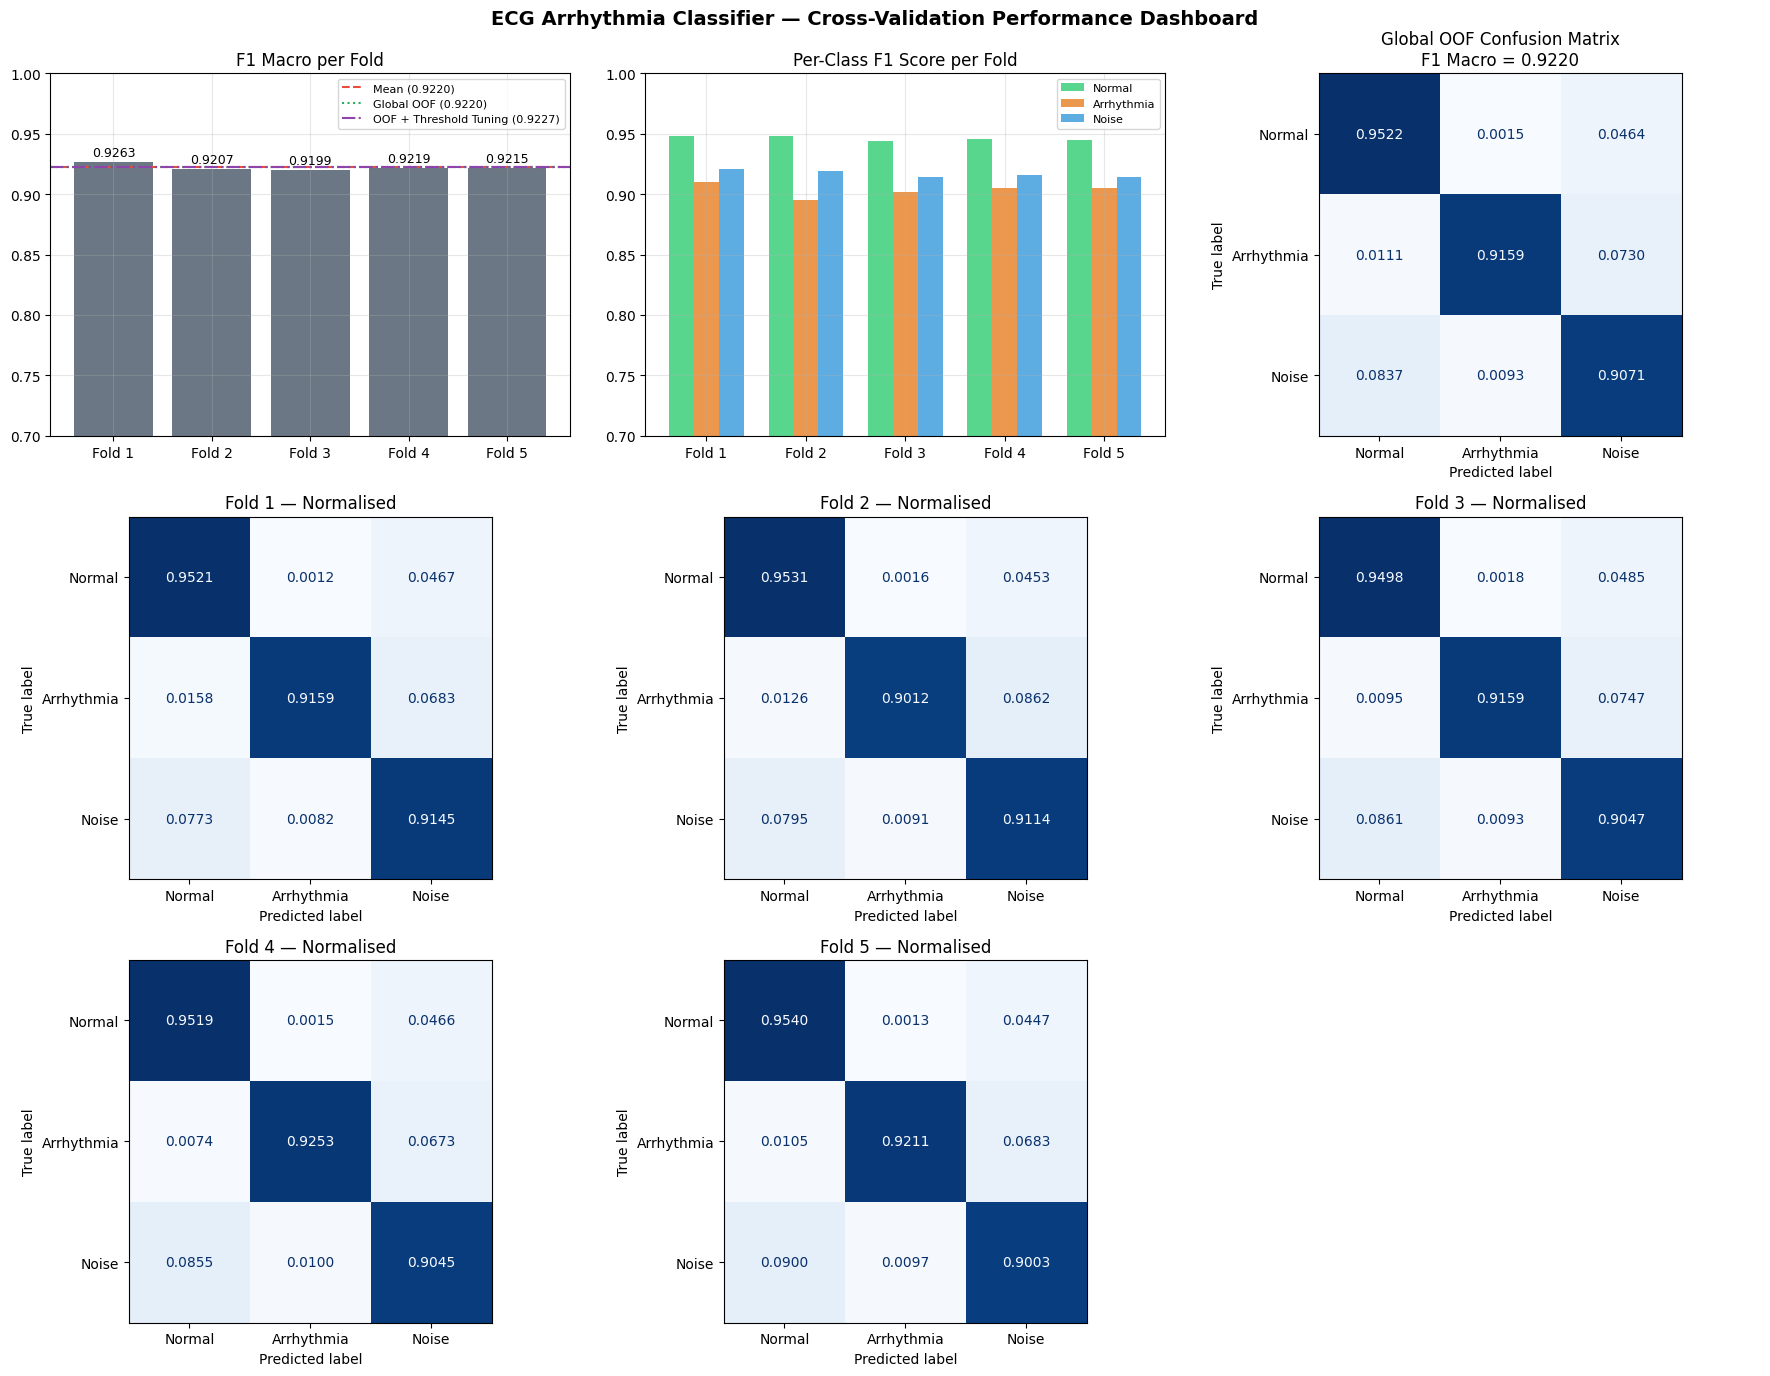


Dashboard saved: /content/drive/MyDrive/Proyecto_DEEP_LEARNING/checkpoints_skf/performance_dashboard.png


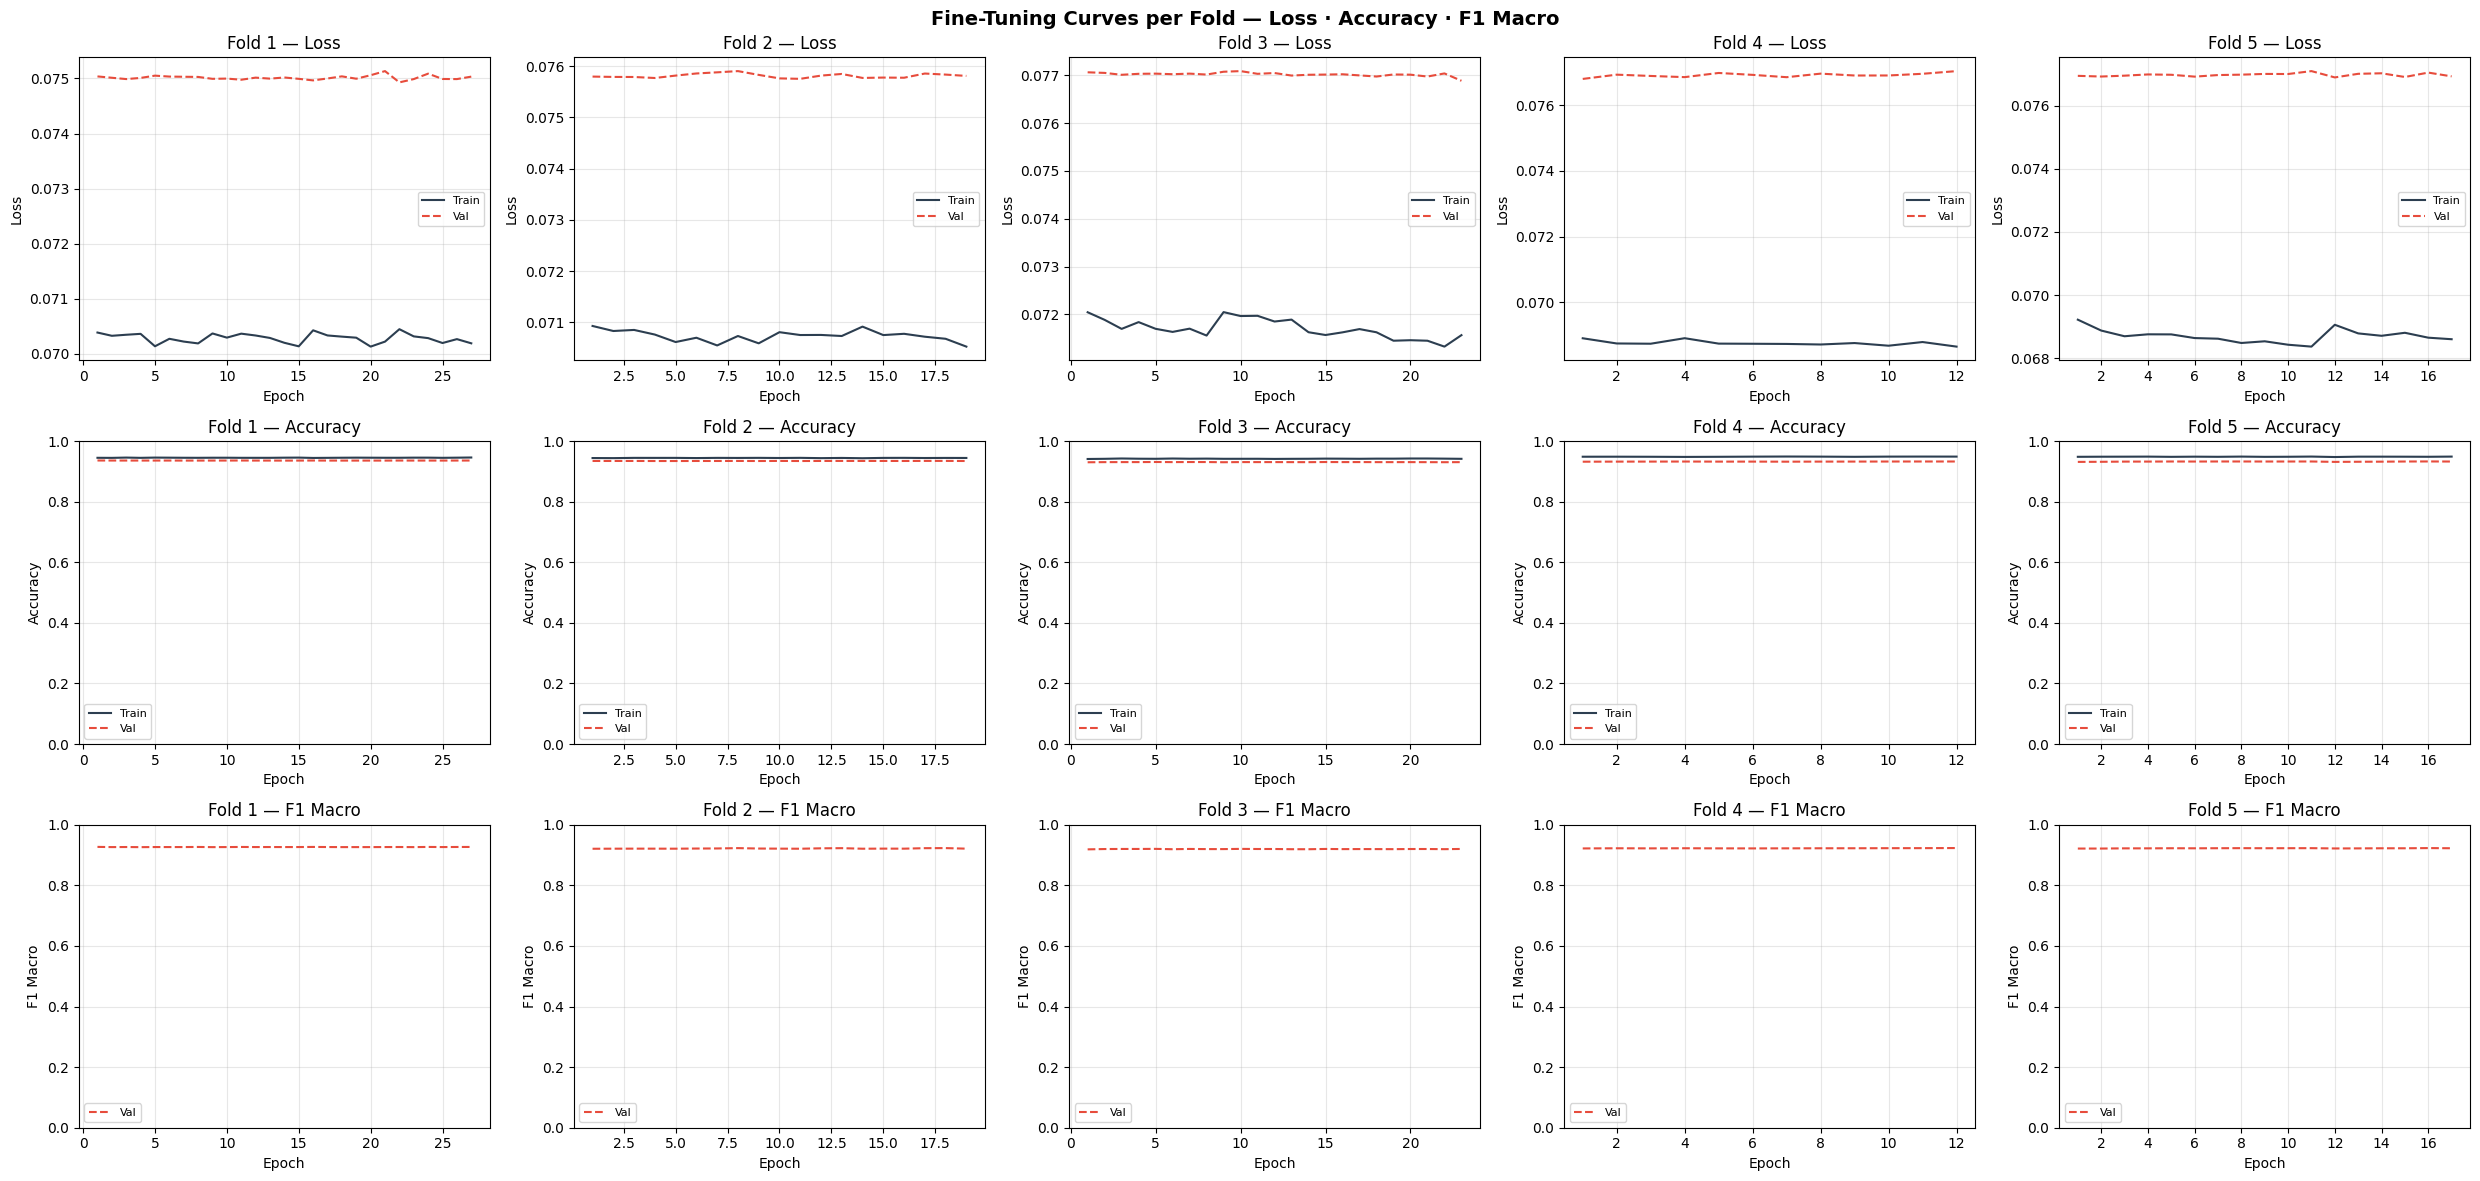

Fine-tuning curves saved : /content/drive/MyDrive/Proyecto_DEEP_LEARNING/checkpoints_skf/finetuning_curves.png


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# VISUALISATION — PERFORMANCE DASHBOARD (5 FOLDS)
# ─────────────────────────────────────────────────────────────────────────────
n_evaluated_folds = len(fold_f1_scores)
fold_labels       = [f"Fold {i + 1}" for i in range(n_evaluated_folds)]
fold_class_f1_arr = np.array(fold_class_f1s)

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle(
    "ECG Arrhythmia Classifier — Cross-Validation Performance Dashboard",
    fontsize=14,
    fontweight="bold",
)

# Panel 1: F1 Macro per fold
ax   = axes[0, 0]
bars = ax.bar(fold_labels, fold_f1_scores, color="#2c3e50", alpha=0.7)
ax.axhline(np.mean(fold_f1_scores), color="#e74c3c", linestyle="--",
           label=f"Mean ({np.mean(fold_f1_scores):.4f})")
ax.axhline(global_macro_f1, color="#27ae60", linestyle=":",
           label=f"Global OOF ({global_macro_f1:.4f})")
ax.axhline(best_macro_f1, color="#8e44ad", linestyle="-.",
           label=f"OOF + Threshold Tuning ({best_macro_f1:.4f})")
for bar, val in zip(bars, fold_f1_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.4f}", ha="center", fontsize=9)
ax.set_title("F1 Macro per Fold")
ax.set_ylim([0.7, 1.0])
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Panel 2: Per-class F1 per fold
ax           = axes[0, 1]
x_pos        = np.arange(n_evaluated_folds)
bar_width    = 0.25
ax.bar(x_pos - bar_width, fold_class_f1_arr[:, 0], bar_width, label="Normal",     color="#2ecc71", alpha=0.8)
ax.bar(x_pos,             fold_class_f1_arr[:, 1], bar_width, label="Arrhythmia", color="#e67e22", alpha=0.8)
ax.bar(x_pos + bar_width, fold_class_f1_arr[:, 2], bar_width, label="Noise",      color="#3498db", alpha=0.8)
ax.set_title("Per-Class F1 Score per Fold")
ax.set_xticks(x_pos)
ax.set_xticklabels(fold_labels)
ax.set_ylim([0.7, 1.0])
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Panel 3: Global OOF confusion matrix (percentage per true class)
ax = axes[0, 2]
plot_confusion_matrix_ratio(
    global_conf_mat, CLASS_NAMES, ax,
    title=f"Global OOF Confusion Matrix\nF1 Macro = {global_macro_f1:.{DIGITS}f}",
)

# Panels 4–8: Per-fold normalised confusion matrices
for i in range(len(fold_conf_matrices)):
    row = 1 + (i // 3)
    col = i % 3
    plot_confusion_matrix_ratio(
        fold_conf_matrices[i], CLASS_NAMES, axes[row, col],
        title=f"Fold {i + 1} — Normalised",
    )

# Hide unused subplot
axes[2, 2].axis("off")

plt.tight_layout()
save_figure_both_formats(plt, dashboard_path)
plt.show()
print(f"\nDashboard saved: {dashboard_path}")

# Plot fine-tuned training curves
plot_training_curves.__doc__  # reuse the same function with finetuned suffix
fig2, axes2 = plt.subplots(3, N_FOLDS, figsize=(5 * N_FOLDS, 12))
fig2.suptitle(
    "Fine-Tuning Curves per Fold — Loss · Accuracy · F1 Macro",
    fontsize=14,
    fontweight="bold",
)
colors = {"train": "#2c3e50", "val": "#e74c3c"}

for fold_idx in range(N_FOLDS):
    ft_history_path = os.path.join(CHECKPOINT_DIR, f"history_fold_{fold_idx + 1}_finetuned.json")

    if not os.path.exists(ft_history_path):
        for row in range(3):
            axes2[row, fold_idx].set_visible(False)
        continue

    with open(ft_history_path, "r") as fp:
        hist = json.load(fp)

    epochs = range(1, len(hist.get("loss", [])) + 1)

    for row, (train_key, val_key, ylabel) in enumerate([
        ("loss",     "val_loss",      "Loss"),
        ("accuracy", "val_accuracy",  "Accuracy"),
        (None,       "val_f1_macro",  "F1 Macro"),
    ]):
        ax = axes2[row, fold_idx]
        if train_key:
            ax.plot(epochs, hist.get(train_key, []), color=colors["train"], label="Train")
        val_data = hist.get(val_key, [])
        ax.plot(epochs, val_data, color=colors["val"], label="Val", linestyle="--")
        if val_data and row in (1, 2):
            ax.set_ylim([0, 1.0])
        ax.set_title(f"Fold {fold_idx + 1} — {ylabel}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

plt.tight_layout()
save_figure_both_formats(plt, ft_curves_path)
plt.show()
print(f"Fine-tuning curves saved : {ft_curves_path}")


Loading ground-truth labels for final test-set evaluation …

FINAL TEST-SET EVALUATION (test_with_labels_200.h5)
  F1-score (weighted): 0.9306
              precision    recall  f1-score   support

      Normal     0.9439    0.9423    0.9431     27891
  Arrhythmia     0.6373    0.7089    0.6712       347
       Noise     0.9166    0.9170    0.9168     18705

    accuracy                         0.9305     46943
   macro avg     0.8326    0.8561    0.8437     46943
weighted avg     0.9308    0.9305    0.9306     46943



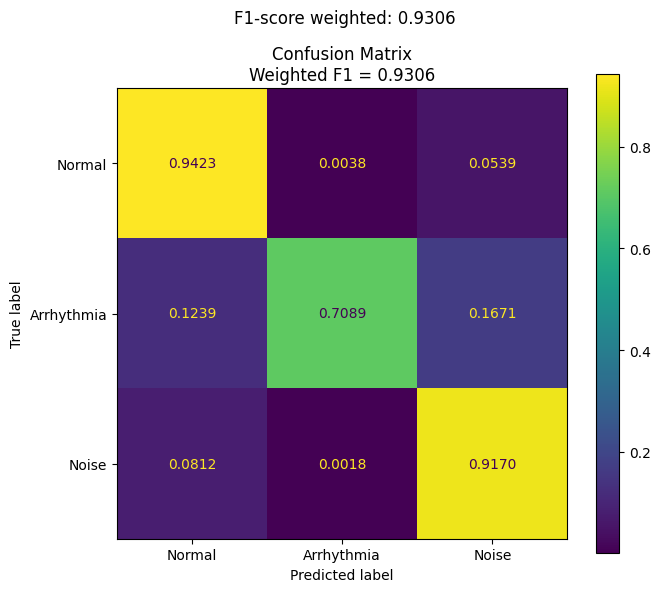


Final test-set confusion matrix saved: /content/drive/MyDrive/Proyecto_DEEP_LEARNING/checkpoints_skf/final_test_confusion_matrix.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# FINAL TEST-SET EVALUATION — WEIGHTED F1 & CONFUSION MATRIX (WITH LABELS)
# ─────────────────────────────────────────────────────────────────────────────

print("\nLoading ground-truth labels for final test-set evaluation …")
with h5py.File(TEST_LABELS_PATH, "r") as h5_file:
    y_test_true = np.squeeze(np.array(h5_file["labels"], dtype=np.int32))

# `final_test_labels` was already computed in the FINAL INFERENCE block above
test_weighted_f1     = f1_score(y_test_true, final_test_labels, average="weighted")
test_conf_matrix     = confusion_matrix(y_test_true, final_test_labels)
test_conf_matrix_ratio = normalize_confusion_matrix(test_conf_matrix)

print(f"\n{'='*60}")
print("FINAL TEST-SET EVALUATION (test_with_labels_200.h5)")
print(f"{'='*60}")
print(f"  F1-score (weighted): {test_weighted_f1:.4f}")
print(classification_report(y_test_true, final_test_labels, target_names=CLASS_NAMES,digits=DIGITS))

fig, ax = plt.subplots(figsize=(7, 6))
fig.suptitle(f"F1-score weighted: {test_weighted_f1:.4f}", fontsize=12, y=0.98)

disp = plot_confusion_matrix_ratio(
    test_conf_matrix_ratio, CLASS_NAMES, ax,
    title=f"Confusion Matrix\nWeighted F1 = {test_weighted_f1:.{DIGITS}f}",
    cmap="viridis",
    already_normalized=True,
    colorbar=True,
)
ax.title.set_fontsize(12)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
save_figure_both_formats(plt, test_eval_path)
plt.show()
print(f"\nFinal test-set confusion matrix saved: {test_eval_path}")

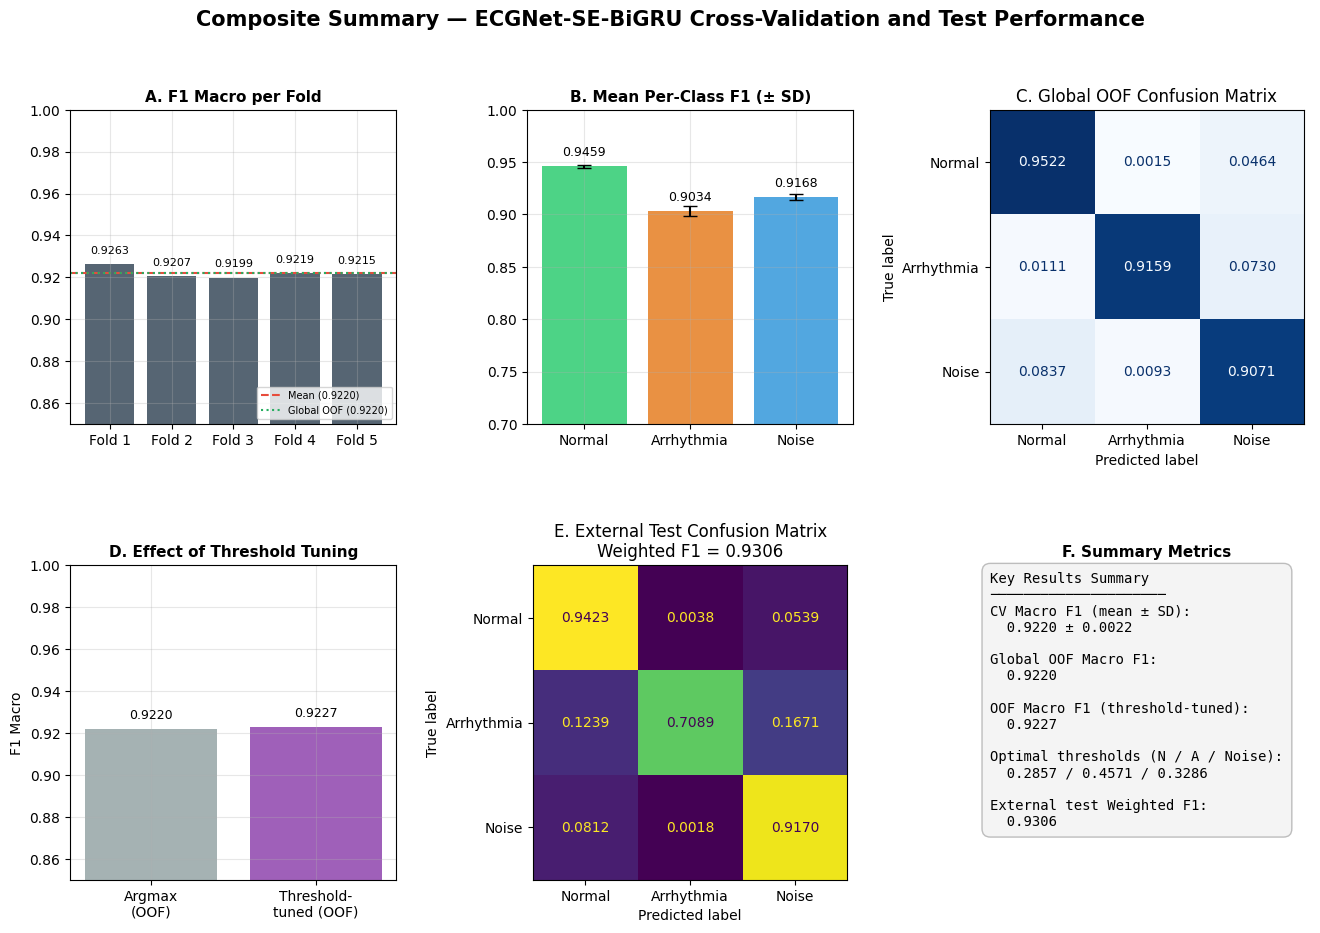

Composite dashboard summary saved in /content/drive/MyDrive/Proyecto_DEEP_LEARNING/checkpoints_skf/composite_dashboard_summary.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# COMPOSITE DASHBOARD SUMMARY — PUBLICATION-READY OVERVIEW FIGURE
# ─────────────────────────────────────────────────────────────────────────────
# Append this block after the "FINAL TEST-SET EVALUATION" section.
# It reuses variables already computed earlier in the script:
#   fold_f1_scores, fold_class_f1s, global_macro_f1, global_conf_mat_pct,
#   best_macro_f1, best_thresholds, test_weighted_f1, test_conf_matrix_pct,
#   final_test_labels, CLASS_NAMES, CHECKPOINT_DIR
# ─────────────────────────────────────────────────────────────────────────────

def plot_composite_summary_dashboard(
    fold_f1_scores: list,
    fold_class_f1_arr: np.ndarray,
    global_macro_f1: float,
    global_conf_mat_pct: np.ndarray,
    best_macro_f1: float,
    best_thresholds: tuple,
    test_weighted_f1: float,
    test_conf_mat_pct: np.ndarray,
    class_names: list,
    checkpoint_dir: str,
) -> None:
    """
    Builds a single composite figure summarizing the full experimental
    pipeline (cross-validation, threshold optimization, and external
    test-set evaluation), intended for use as a graphical abstract /
    results-summary figure in the manuscript.
    """
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 1], hspace=0.45, wspace=0.4)
    fig.suptitle(
        "Composite Summary — ECGNet-SE-BiGRU Cross-Validation and Test Performance",
        fontsize=15, fontweight="bold", y=0.98,
    )

    fold_labels = [f"Fold {i + 1}" for i in range(len(fold_f1_scores))]

    # ── Panel A: F1 Macro per fold ──────────────────────────────────────────
    ax = fig.add_subplot(gs[0, 0])
    bars = ax.bar(fold_labels, fold_f1_scores, color="#2c3e50", alpha=0.8)
    ax.axhline(np.mean(fold_f1_scores), color="#e74c3c", linestyle="--",
               label=f"Mean ({np.mean(fold_f1_scores):.4f})")
    ax.axhline(global_macro_f1, color="#27ae60", linestyle=":",
               label=f"Global OOF ({global_macro_f1:.4f})")
    for bar, val in zip(bars, fold_f1_scores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.4f}", ha="center", fontsize=8)
    ax.set_title("A. F1 Macro per Fold", fontsize=11, fontweight="bold")
    ax.set_ylim([0.85, 1.0])
    ax.legend(fontsize=7, loc="lower right")
    ax.grid(alpha=0.3)

    # ── Panel B: Per-class F1 (mean across folds) ───────────────────────────
    ax = fig.add_subplot(gs[0, 1])
    mean_class_f1 = fold_class_f1_arr.mean(axis=0)
    std_class_f1 = fold_class_f1_arr.std(axis=0)
    bar_colors = ["#2ecc71", "#e67e22", "#3498db"]
    bars = ax.bar(class_names, mean_class_f1, yerr=std_class_f1,
                   color=bar_colors, alpha=0.85, capsize=5)
    for bar, val in zip(bars, mean_class_f1):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.4f}", ha="center", fontsize=9)
    ax.set_title("B. Mean Per-Class F1 (± SD)", fontsize=11, fontweight="bold")
    ax.set_ylim([0.7, 1.0])
    ax.grid(alpha=0.3)

    # ── Panel C: Global OOF confusion matrix ────────────────────────────────
    plot_confusion_matrix_ratio(
    global_conf_mat, class_names, fig.add_subplot(gs[0, 2]),
    title="C. Global OOF Confusion Matrix",
    )

    # ── Panel D: Effect of threshold optimization ───────────────────────────
    ax = fig.add_subplot(gs[1, 0])
    stages = ["Argmax\n(OOF)", "Threshold-\ntuned (OOF)"]
    values = [global_macro_f1, best_macro_f1]
    bars = ax.bar(stages, values, color=["#95a5a6", "#8e44ad"], alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.4f}", ha="center", fontsize=9)
    ax.set_title("D. Effect of Threshold Tuning", fontsize=11, fontweight="bold")
    ax.set_ylabel("F1 Macro")
    ax.set_ylim([0.85, 1.0])
    ax.grid(alpha=0.3)

    # ── Panel E: External test-set confusion matrix ─────────────────────────
    plot_confusion_matrix_ratio(
        test_conf_mat_pct, class_names, fig.add_subplot(gs[1, 1]),
        title=f"E. External Test Confusion Matrix\nWeighted F1 = {test_weighted_f1:.{DIGITS}f}",
        cmap="viridis",
        already_normalized=True,
    )

    # ── Panel F: Key-metrics summary box ────────────────────────────────────
    ax = fig.add_subplot(gs[1, 2])
    ax.axis("off")
    th0, th1, th2 = best_thresholds
    summary_text = (
        "Key Results Summary\n"
        "─────────────────────\n"
        f"CV Macro F1 (mean ± SD):\n  {np.mean(fold_f1_scores):.4f} ± {np.std(fold_f1_scores):.4f}\n\n"
        f"Global OOF Macro F1:\n  {global_macro_f1:.4f}\n\n"
        f"OOF Macro F1 (threshold-tuned):\n  {best_macro_f1:.4f}\n\n"
        f"Optimal thresholds (N / A / Noise):\n  {th0:.4f} / {th1:.4f} / {th2:.4f}\n\n"
        f"External test Weighted F1:\n  {test_weighted_f1:.4f}"
    )
    ax.text(0.02, 0.98, summary_text, transform=ax.transAxes,
            fontsize=10, va="top", ha="left", family="monospace",
            bbox=dict(boxstyle="round,pad=0.6", facecolor="#f4f4f4", edgecolor="#bdbdbd"))
    ax.set_title("F. Summary Metrics", fontsize=11, fontweight="bold")

    save_figure_both_formats(plt, dashboard_summary_path)
    plt.show()
    print(f"Composite dashboard summary saved in {dashboard_summary_path}")

plot_composite_summary_dashboard(
    fold_f1_scores=fold_f1_scores,
    fold_class_f1_arr=np.array(fold_class_f1s),
    global_macro_f1=global_macro_f1,
    global_conf_mat_pct=global_conf_mat_ratio,
    best_macro_f1=best_macro_f1,
    best_thresholds=best_thresholds,
    test_weighted_f1=test_weighted_f1,
    test_conf_mat_pct=test_conf_matrix_ratio,
    class_names=CLASS_NAMES,
    checkpoint_dir=CHECKPOINT_DIR,
)